In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
df = pd.read_csv('economy_cleaned.csv', low_memory=False)

In [4]:
df['via_city'] = df['via_city'].fillna(
    pd.Series(np.where(df['stop_count'] == 0, 'Direct', 'Not_Recorded'), index=df.index)
)

In [5]:
df.sample(10)

,date,airline,ch_code,flight_number,from,to,via_city,route,stop_count,arr_hour,arr_period,dep_hour,dep_period,duration_mins,price
162910,2022-03-13,Vistara,UK,898,Hyderabad,Mumbai,Not_Recorded,Hyderabad-Mumbai,1,16,Afternoon,7,Morning,530,8133
79423,2022-02-27,Vistara,UK,940,Mumbai,Chennai,Not_Recorded,Mumbai-Chennai,1,9,Morning,19,Evening,850,5313
95064,2022-02-18,Air India,AI,501,Bangalore,Mumbai,Not_Recorded,Bangalore-Mumbai,1,21,Night,13,Afternoon,495,9277
39164,2022-03-09,AirAsia,I5,550,Delhi,Chennai,Not_Recorded,Delhi-Chennai,1,23,Night,16,Afternoon,385,1998
56287,2022-03-03,Vistara,UK,902,Mumbai,Bangalore,Not_Recorded,Mumbai-Bangalore,1,22,Night,15,Afternoon,415,6450
168457,2022-03-11,Vistara,UK,876,Hyderabad,Bangalore,Not_Recorded,Hyderabad-Bangalore,1,10,Morning,21,Night,790,5441
99183,2022-03-12,GO FIRST,G8,118,Bangalore,Mumbai,Not_Recorded,Bangalore-Mumbai,1,10,Morning,21,Night,735,5177
48515,2022-03-11,Vistara,UK,873,Mumbai,Delhi,Not_Recorded,Mumbai-Delhi,1,12,Afternoon,6,Morning,380,5547
60996,2022-03-29,Vistara,UK,863,Mumbai,Bangalore,Direct,Mumbai-Bangalore,0,10,Morning,9,Morning,100,2074
27188,2022-03-23,SpiceJet,SG,480,Delhi,Kolkata,Not_Recorded,Delhi-Kolkata,1,21,Night,17,Evening,255,4080


## `Feature Engineering` (day_of_week yaha add kiya, baaki cleaning ke time add ho chuke the)

**`route` column `from` & `to` ko join karke banaya gaya**

**`arr_period` & `dep_period` columns `arr_hrs` & `dep_hrs` ko day-cycle buckets mein daal ke bane**

**`stop_count` sirf number of stoppages hai, `stop` column se extract kiya**

**`via_city` `stop` column se extract kiya — economy mein sirf 2.5% stopped flights mein hi city record thi, baaki `Not_Recorded`**

**`day_of_week` date column se extract kiya, phir `is_weekend` `day_of_week` se**

**`days_left` economy mein nahi hai — Clean_Dataset.csv se reliable join nahi ho paya (~85% rows ambiguous nikle the)**

In [6]:
df['date'] = pd.to_datetime(df['date'])

df['day_of_week'] = df['date'].dt.day_name()

df['is_weekend'] = np.where(df['day_of_week'].isin(['Saturday','Sunday']), 1, 0)

In [7]:
order = ['date', 'day_of_week','is_weekend', 'airline', 'ch_code', 'flight_number', 'from', 'to',
         'via_city','route', 'stop_count', 'arr_hour', 'arr_period', 'dep_hour',
         'dep_period', 'duration_mins', 'price'
        ]

df = df[order]
df.columns

Index(['date', 'day_of_week', 'is_weekend', 'airline', 'ch_code',
       'flight_number', 'from', 'to', 'via_city', 'route', 'stop_count',
       'arr_hour', 'arr_period', 'dep_hour', 'dep_period', 'duration_mins',
       'price'],
      dtype='object')

## Dropping unneccessary columns

In [8]:
df.drop(columns=['date','ch_code'], inplace=True)

In [9]:
X = df.drop(columns=['price'])
y = df['price']

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)

In [11]:
X_train.sample(5)

,day_of_week,is_weekend,airline,flight_number,from,to,via_city,route,stop_count,arr_hour,arr_period,dep_hour,dep_period,duration_mins
65891,Tuesday,0,Air India,867,Mumbai,Kolkata,Not_Recorded,Mumbai-Kolkata,1,9,Morning,21,Night,690
110033,Tuesday,0,Vistara,858,Bangalore,Hyderabad,Not_Recorded,Bangalore-Hyderabad,1,20,Night,6,Morning,855
186599,Friday,0,Air India,440,Chennai,Delhi,Direct,Chennai-Delhi,0,8,Morning,6,Morning,160
68247,Sunday,1,Vistara,910,Mumbai,Kolkata,Not_Recorded,Mumbai-Kolkata,1,8,Morning,17,Evening,900
9274,Monday,0,Vistara,706,Delhi,Mumbai,Not_Recorded,Delhi-Mumbai,1,21,Night,13,Afternoon,475


In [12]:
X_test.sample(5)

,day_of_week,is_weekend,airline,flight_number,from,to,via_city,route,stop_count,arr_hour,arr_period,dep_hour,dep_period,duration_mins
46699,Thursday,0,AirAsia,1569,Mumbai,Delhi,Not_Recorded,Mumbai-Delhi,1,3,Late_Night,21,Night,360
132885,Wednesday,0,Indigo,893,Kolkata,Mumbai,Not_Recorded,Kolkata-Mumbai,1,20,Night,9,Morning,700
171353,Thursday,0,Air India,559,Hyderabad,Kolkata,Not_Recorded,Hyderabad-Kolkata,2,19,Evening,6,Morning,760
190572,Sunday,1,Air India,539,Chennai,Mumbai,Not_Recorded,Chennai-Mumbai,1,9,Morning,17,Evening,965
199433,Sunday,1,Indigo,5367,Chennai,Kolkata,Not_Recorded,Chennai-Kolkata,1,1,Late_Night,18,Evening,405


-------------------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------------------------------
##                                                       LinearRegressor Model
-------------------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------------------------------

In [13]:
categorical_features = ['day_of_week','airline','route','arr_period','dep_period']

numerical_features = ['stop_count','duration_mins']

binary_count = ['is_weekend']

In [14]:
# preprocessing for LinearRegression
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown= 'ignore'), categorical_features),
    ('bin', 'passthrough', binary_count)
])

In [15]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [16]:
X_train_encoded.shape

(165417, 53)

In [17]:
X_test.shape

(41355, 14)

In [18]:
lr = LinearRegression()

In [19]:
lr.fit(X_train_encoded,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


**Shape[1] of X_train after preprocessing will be equal to the number of coefficients of the Linear Regression equation**

In [20]:
print('Coefficients of linear regression:',lr.coef_)

print('\nintercept:',lr.intercept_)

Coefficients of linear regression: [  811.53313101   331.29906352  -638.81255471    14.7519042
   -11.6813578   -640.93515728  -761.36251658  -673.27381829
 -2934.83454924 -1152.73550969 -1209.11617127  -621.17889215
   160.31386109 -2934.48425994   595.3384785    214.02241981
  -371.69768328   948.6126741    115.1241787     10.07880096
  -214.40655863  -783.81947022   960.24507102   -13.72892356
   162.12696697  -308.11571176  -328.27831397   701.93869368
    39.99252098  -364.37304142  -540.77450587  -163.96960736
   307.1356711   -655.34490473  1041.19111215  1305.84914376
  1076.46116254   810.01317122   792.95890663   102.38469396
  -357.82941589   -93.20355134 -1049.94886382   649.20495988
   104.90835561  -304.75781088  -521.83820884   -36.03976646
  -203.50772492   175.21765024   102.71679618  -254.25208831
     3.07054639]

intercept: 7419.96021540124


In [21]:
y_pred_lr = lr.predict(X_test_encoded)

## Linear Regression — Summary

- `duration_mins` ko numeric feature mein rakha (koi bucket substitute nahi hai iske liye, `arr_hour`/`dep_hour` jaisa nahi)
- `via_city` nahi liya — economy mein 97.5% stopped flights ki via_city missing hai, jo mila hai wo bhi `stop_count` se hi redundant nikla
- Bucketed `arr_period`/`dep_period` use kiya, raw hour nahi (business jaisa hi reasoning)
- **R² = 0.2193, RMSE = ₹3,305 (57.13% of median price)**

-------------------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------------------------------
##                                                       RandomForestRegressor Model
-------------------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------------------------------

**Since random forest works fine with outliers in Regression than Linear regression therefore we are feeding features without bucketng them**

**Scaling is also not needed here**

In [22]:
categorical_features = ['day_of_week','airline','from','to','route']

numerical_features = ['stop_count','flight_number','arr_hour','dep_hour','duration_mins']

binary_features = ['is_weekend']

In [23]:
preprocessor = ColumnTransformer([
    ('num', 'passthrough', numerical_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown= 'ignore'), categorical_features),
    ('bin', 'passthrough', binary_features)
])

In [24]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [25]:
X_train_encoded.shape

(165417, 58)

In [26]:
X_test.shape

(41355, 14)

In [27]:
rf = RandomForestRegressor(
    n_estimators=200,       # number of trees — more = more stable predictions, diminishing returns past ~200-300
    max_depth=15,           # cap tree depth — prevents individual trees from overfitting to noise
    min_samples_split=5,    # minimum samples needed to split a node — higher = less overfitting
    min_samples_leaf=2,     # minimum samples allowed in a leaf — smooths out predictions
    max_features='sqrt',    # each split considers only a random subset of features — reduces correlation between trees
    n_jobs=-1,               # use all CPU cores — speeds up training significantly
    random_state=42          # fixes randomness so results are reproducible
)

In [28]:
rf.fit(X_train_encoded,y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,15
,min_samples_split,5
,min_samples_leaf,2
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
y_pred_rf = rf.predict(X_test_encoded)

## Random Forest — Summary

- Scaling nahi ki, raw `arr_hour`/`dep_hour`/`duration_mins` use kiya (business jaisa hi)
- `flight_number` bhi feature ki tarah liya — same memorization caution jo business mein tha, yaha bhi valid hai
- **R² = 0.3172, RMSE = ₹3,091 (53.42% of median price)**

-------------------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------------------------------
##                                                       XGBRegressor Model
-------------------------------------------------------------------------------------------------------------------------------------------------------
-------------------------------------------------------------------------------------------------------------------------------------------------------

In [30]:
from xgboost import XGBRegressor

In [31]:
categorical_features = ['day_of_week','airline','route','arr_period','dep_period']

numerical_features = ['stop_count','flight_number','duration_mins']

binary_count = ['is_weekend']

In [32]:
preprocessor = ColumnTransformer([
    ('num', 'passthrough', numerical_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown= 'ignore'), categorical_features),
    ('bin', 'passthrough', binary_count)
])

In [33]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

In [34]:
xgb =XGBRegressor(
    n_estimators = 200,
    learning_rate = 0.1,
    random_state= 42,
    max_depth= 6,
    n_jobs = -1
)

In [35]:
xgb.fit(X_train_encoded,y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,None


In [36]:
y_pred_xgb = xgb.predict(X_test_encoded)

In [37]:
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
print('LR — R2:', r2_lr, ' RMSE:', rmse_lr, ' RMSE% of median:', (rmse_lr/y_test.median())*100)

r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
print('RF — R2:', r2_rf, ' RMSE:', rmse_rf, ' RMSE% of median:', (rmse_rf/y_test.median())*100)

r2_xgb = r2_score(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
print('XGB — R2:', r2_xgb, ' RMSE:', rmse_xgb, ' RMSE% of median:', (rmse_xgb/y_test.median())*100)

LR — R2: 0.21928974320367423  RMSE: 3305.3120176417615  RMSE% of median: 57.12602864918357
RF — R2: 0.3172354770453023  RMSE: 3091.0283868142687  RMSE% of median: 53.42254384400741
XGB — R2: 0.3490915894508362  RMSE: 3018.0571565164237  RMSE% of median: 52.161374983000755


## XGBoost — Summary

- Same feature set jo LR mein use kiya (bucketed periods, `flight_number`, `duration_mins`, `via_city` excluded)
- **R² = 0.3491, RMSE = ₹3,018 (52.16% of median price) — teeno models mein best, business jaisa hi pattern**
- Ceiling still economy ke structural data-limitation se bandhi hai (52% unexplainable within-group variance) — best model bhi is limit ko cross nahi kar sakta

## Data Ceiling Check

- Business ke comparison mein economy ke R² scores kaafi kam honge — ye modeling ki galti nahi hai
- Tested: identical flights (same airline, route, stops, duration, time period) ke liye bhi price variance hai — within-group price std, overall std ka ~52% hai
- Matlab: aadhe se zyada price variance kisi bhi available feature se explain hi nahi hota — most likely missing `days_left`-jaisa booking-date signal
- Ye ek genuine data limitation hai, models ki kami nahi

## y_test Vs y_pred Vs Perfect Prediction Line Plot comparision

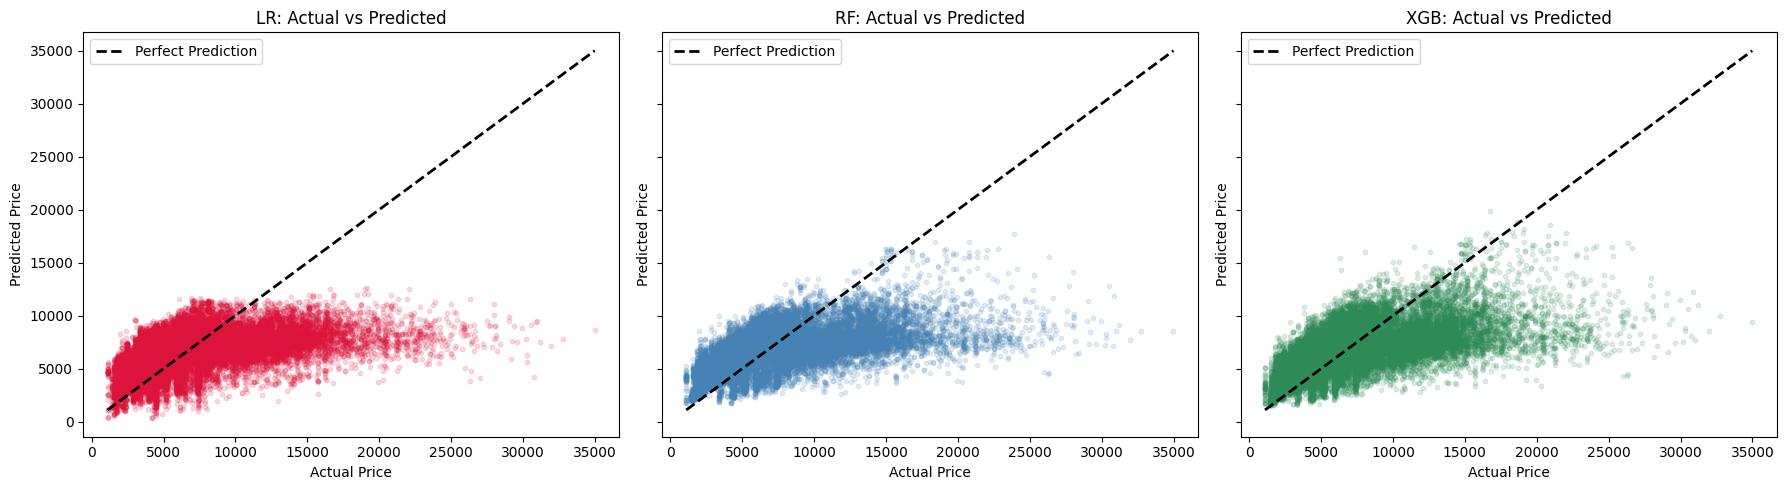

In [38]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)

axes[0].scatter(y_test, y_pred_lr, s=10, alpha=0.15, color='crimson')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2, linestyle='--', color='black', label='Perfect Prediction')
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title('LR: Actual vs Predicted')
axes[0].legend()

axes[1].scatter(y_test, y_pred_rf, s=10, alpha=0.15, color='steelblue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2, linestyle='--', color='black', label='Perfect Prediction')
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title('RF: Actual vs Predicted')
axes[1].legend()

axes[2].scatter(y_test, y_pred_xgb, s=10, alpha=0.15, color='seagreen')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linewidth=2, linestyle='--', color='black', label='Perfect Prediction')
axes[2].set_xlabel('Actual Price')
axes[2].set_ylabel('Predicted Price')
axes[2].set_title('XGB: Actual vs Predicted')
axes[2].legend()

plt.tight_layout()
plt.show()

## y_pred_lr Vs Residuals Vs 0 error line plot comparision

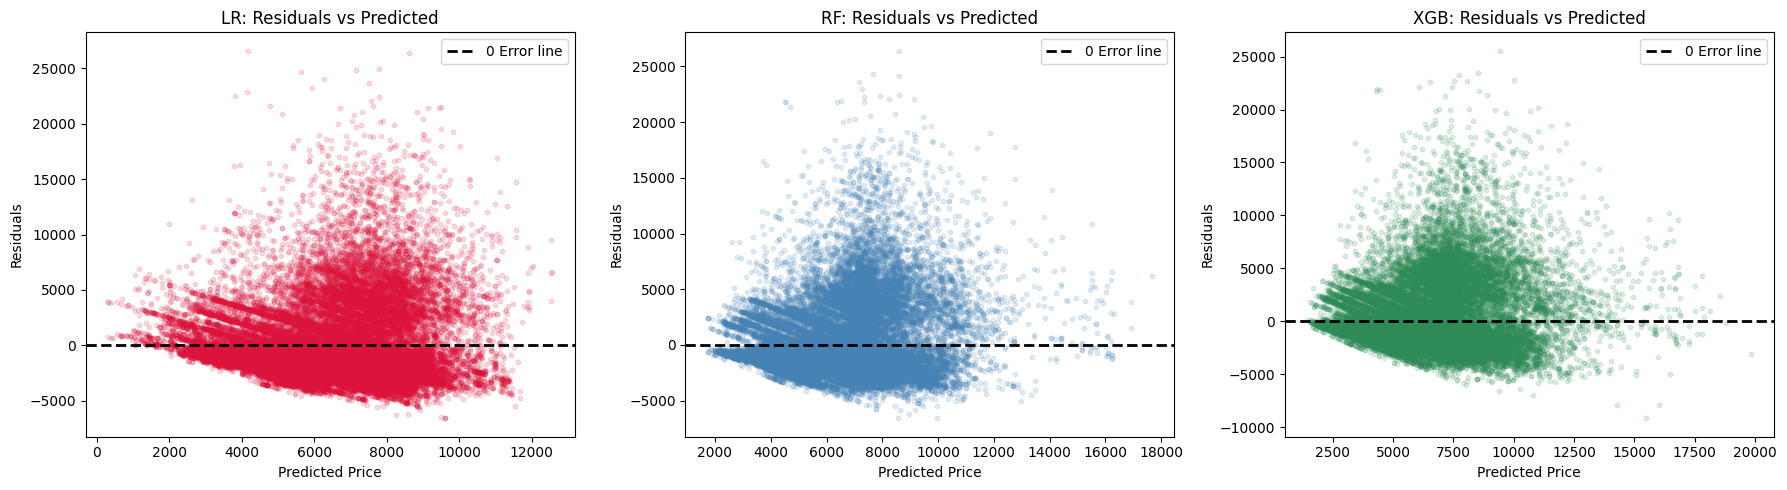

In [39]:
residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf
residuals_xgb = y_test - y_pred_xgb

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_pred_lr, residuals_lr, color='crimson', s=10, alpha=0.15)
axes[0].axhline(y=0, color='black', linewidth=2, linestyle='--', label='0 Error line')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residuals')
axes[0].set_title('LR: Residuals vs Predicted')
axes[0].legend()

axes[1].scatter(y_pred_rf, residuals_rf, color='steelblue', s=10, alpha=0.15)
axes[1].axhline(y=0, color='black', linewidth=2, linestyle='--', label='0 Error line')
axes[1].set_xlabel('Predicted Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('RF: Residuals vs Predicted')
axes[1].legend()

axes[2].scatter(y_pred_xgb, residuals_xgb, color='seagreen', s=10, alpha=0.15)
axes[2].axhline(y=0, color='black', linewidth=2, linestyle='--', label='0 Error line')
axes[2].set_xlabel('Predicted Price')
axes[2].set_ylabel('Residuals')
axes[2].set_title('XGB: Residuals vs Predicted')
axes[2].legend()

plt.tight_layout()
plt.show()

## Residuals distribution and skewness comparision

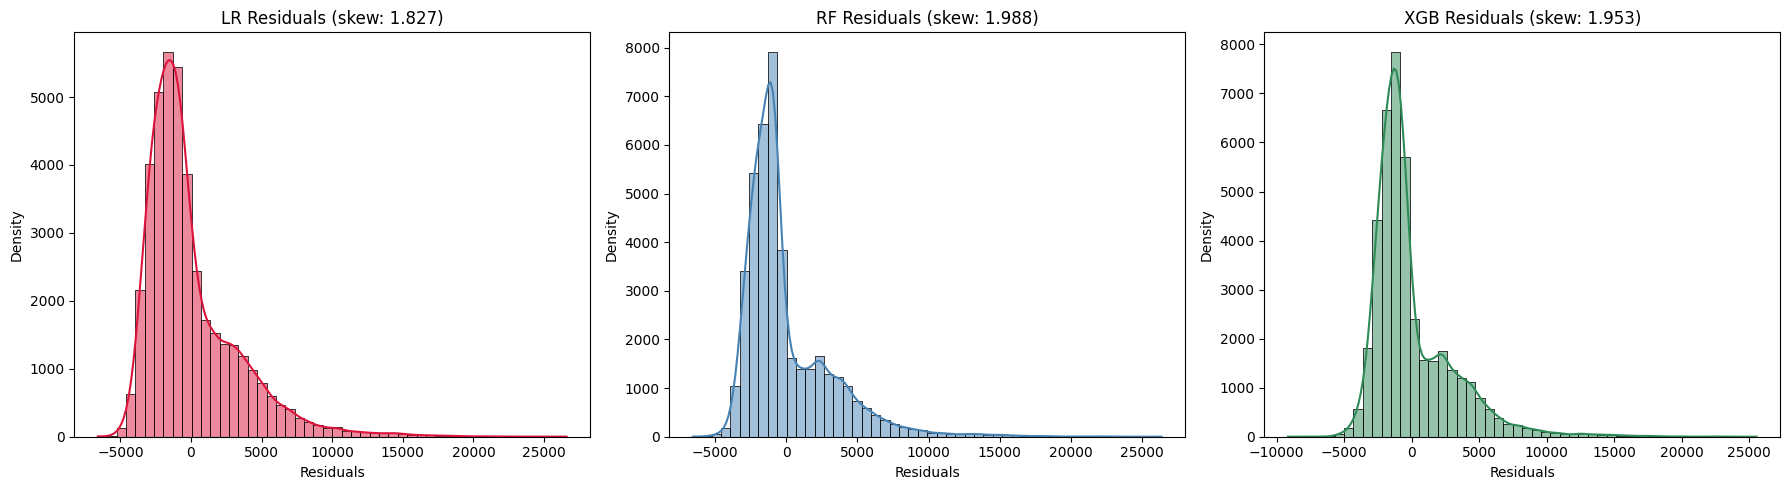

LR residuals skew: 1.8267323918301743
RF residuals skew: 1.9875481510817596
XGB residuals skew: 1.9530054039461227


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(residuals_lr, bins=50, kde=True, color='crimson', ax=axes[0])
axes[0].set_xlabel('Residuals')
axes[0].set_ylabel('Density')
axes[0].set_title(f'LR Residuals (skew: {residuals_lr.skew():.3f})')

sns.histplot(residuals_rf, bins=50, kde=True, color='steelblue', ax=axes[1])
axes[1].set_xlabel('Residuals')
axes[1].set_ylabel('Density')
axes[1].set_title(f'RF Residuals (skew: {residuals_rf.skew():.3f})')

sns.histplot(residuals_xgb, bins=50, kde=True, color='seagreen', ax=axes[2])
axes[2].set_xlabel('Residuals')
axes[2].set_ylabel('Density')
axes[2].set_title(f'XGB Residuals (skew: {residuals_xgb.skew():.3f})')

plt.tight_layout()
plt.show()

print('LR residuals skew:', residuals_lr.skew())
print('RF residuals skew:', residuals_rf.skew())
print('XGB residuals skew:', residuals_xgb.skew())

## Final Comparison — Economy Class

| Model | R² | RMSE | RMSE % of median |
|---|---|---|---|
| Linear Regression | 0.2193 | ₹3,305 | 57.13% |
| Random Forest | 0.3172 | ₹3,091 | 53.42% |
| XGBoost | 0.3491 | ₹3,018 | 52.16% |

- Business ke comparison mein sab models ka R² kaafi kam hai — data ceiling ki wajah se (upar explain kiya)
- Trend wahi raha: XGB > RF > LR, same reasoning — non-linear patterns tree-based models better pakadte hain
- Business mein RF/XGB ka LR se gap bahut bada tha (0.26+), yaha gap chota hai (~0.13) — kyunki `days_left` jaisa strong non-linear signal economy mein available hi nahi hai jo tree models exploit kar sake